In [24]:
from datasets import Dataset
from transformers import pipeline
from automatic_labeling import label_and_eval
from matplotlib import pyplot as plt
from metrics import return_all_metrics, most_common_fn, most_common_fp, confusion_matrix, show_words

### Get the Dataset and the Model

In [2]:
ds = Dataset.from_csv("../data/edible_test_set.csv")

In [3]:
true_labels = list(ds["manual_label"])

In [4]:
classifier = pipeline(
    "zero-shot-classification", 
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    batch_size=16   
)

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5589.86it/s]


### Test different Labels and Hypothesis

#### Base Experiment

In [ ]:
hypothesis_template="Dieser Artikel ist {}."
labels = [
    "Lebensmittel für Menschen",
    "kein Lebensmittel"
]

In [ ]:
results = label_and_eval(
    classifier, labels, hypothesis_template, ds, batch_size=8
)

In [ ]:
return_all_metrics(results["classes"])

In [ ]:
len(true_labels), len(results["predicted"])

In [ ]:
confusion_matrix(true_labels, results["predicted"])

In [ ]:
show_words(most_common_fn(ds, results["classes"]))

In [ ]:
show_words(most_common_fp(ds, results["classes"]))

Salz, Gewürz und Kräuter befindet sich unter den False negatives <br>
-> in den labeln festhalten <br>
Wein, Punsch <br>
-> alkoholische getränke mit aufnehmen <br>
Berglinsen?

#### Incorporate the items listed above in the label

In [5]:
hypothesis_template="Dieser Artikel ist {}."
labels = [
    "ein Getränk, Gewürz oder ein anderes zum Verzehr geeignetes Lebensmittel",
    "kein Lebensmittel"
]

In [6]:
results = label_and_eval(
    classifier, labels, hypothesis_template, ds, batch_size=8
)

100%|██████████| 100/100 [01:52<00:00,  1.12s/it]


In [7]:
return_all_metrics(results["classes"])

{'accuracy': 0.36,
 'precision': 0.8571424489797862,
 'sensitivity': 0.2278480724242946,
 'specifity': 0.8571424489797862}

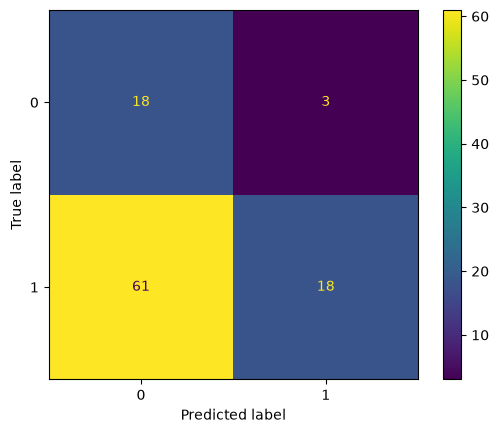

In [8]:
confusion_matrix(true_labels, results["predicted"])

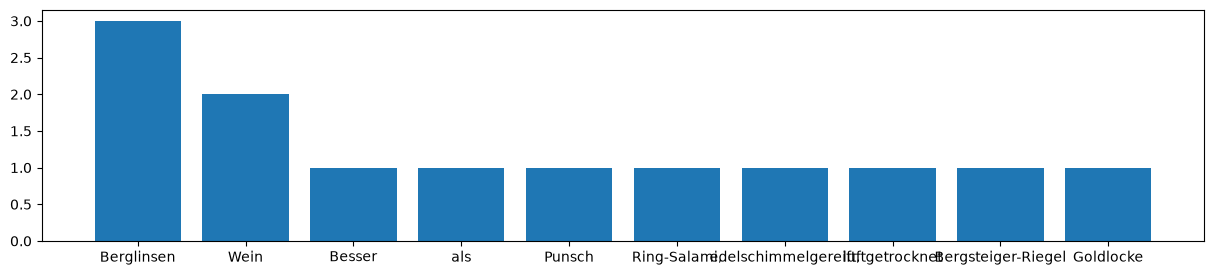

In [9]:
show_words(most_common_fn(ds, results["classes"]))

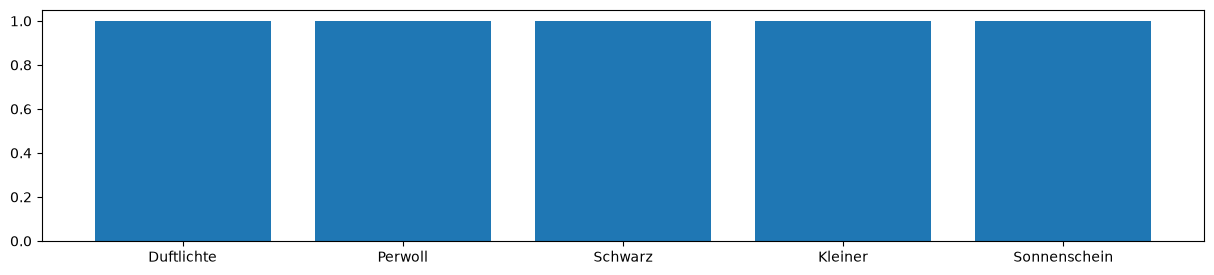

In [10]:
show_words(most_common_fp(ds, results["classes"]))

#### Be more specific for the positive label, add even more items to the postive label

In [ ]:
hypothesis_template="Dieser Artikel ist {}."
labels = [
    "ein Getränk, alkoholisches Getränk, Gewürz, Hülsenfrucht oder ein anderes zum Verzehr geeignetes Lebensmittel",
    "nicht zum menschlichen Verzehr geeignet"
]

In [12]:
results = label_and_eval(
    classifier, labels, hypothesis_template, ds, batch_size=8
)

100%|██████████| 100/100 [02:22<00:00,  1.42s/it]


In [13]:
return_all_metrics(results["classes"])

{'accuracy': 0.34,
 'precision': 0.8421048199448317,
 'sensitivity': 0.20253161993270632,
 'specifity': 0.8571424489797862}

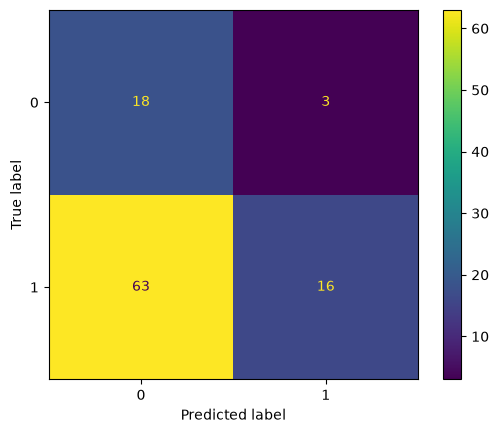

In [14]:
confusion_matrix(true_labels, results["predicted"])

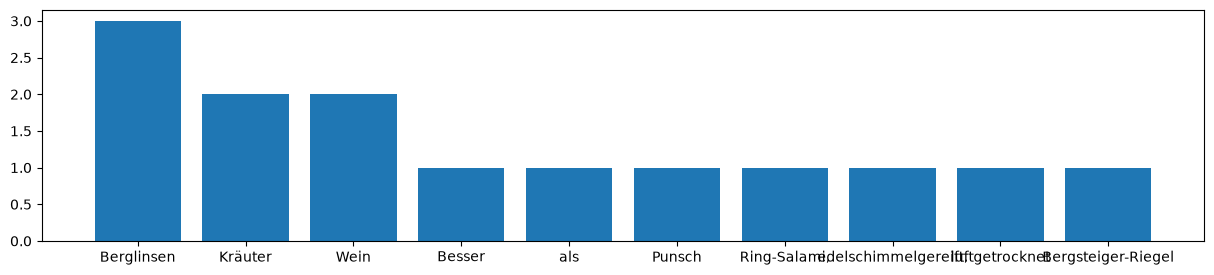

In [15]:
show_words(most_common_fn(ds, results["classes"]))

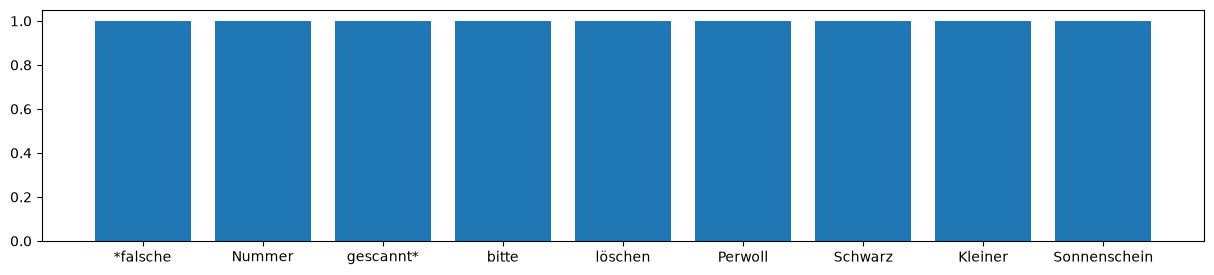

In [16]:
show_words(most_common_fp(ds, results["classes"]))

### Changing the label for the negative class

In [17]:
hypothesis_template="Dieser Artikel ist {}."
labels = [
    "ein Getränk, Gewürz oder ein anderes zum Verzehr geeignetes Lebensmittel",
    "nicht zum menschlichen Verzehr geeignet"
]

In [18]:
results = label_and_eval(
    classifier, labels, hypothesis_template, ds, batch_size=8
)

100%|██████████| 100/100 [01:46<00:00,  1.06s/it]


In [19]:
return_all_metrics(results["classes"])

{'accuracy': 0.41,
 'precision': 0.9166662847223814,
 'sensitivity': 0.2784809774074712,
 'specifity': 0.9047614739231077}

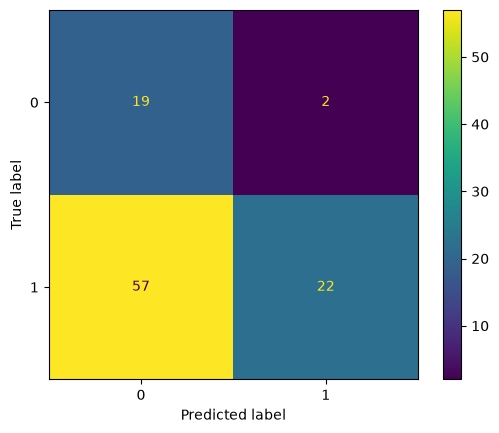

In [20]:
confusion_matrix(true_labels, results["predicted"])

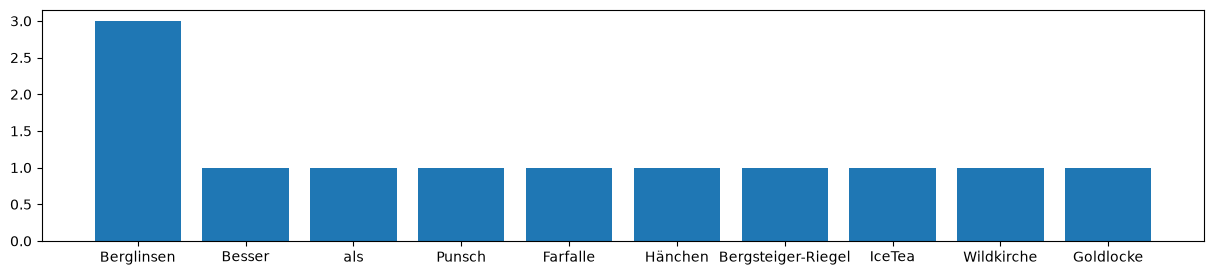

In [21]:
show_words(most_common_fn(ds, results["classes"]))

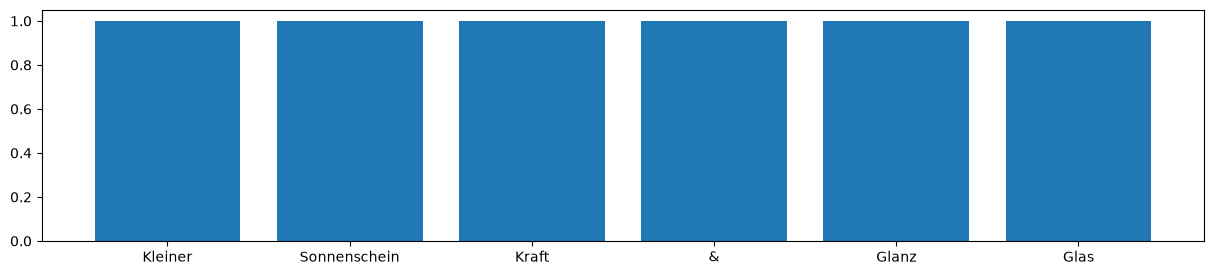

In [22]:
show_words(most_common_fp(ds, results["classes"]))

### Comparing Accuracy of labeling strategies

In [35]:
accs = [0.21, 0.36, 0.34, 0.41]
labels = ["Base", "improving positive label", "adding even more", "improving both positive and negative label"]

Text(0, 0.5, 'Accuracy')

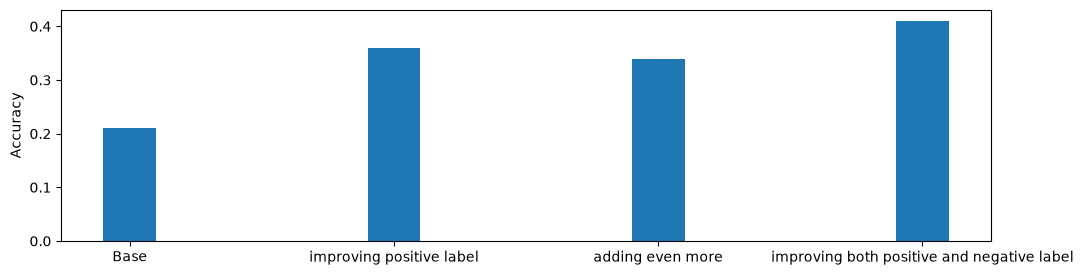

In [37]:
plt.figure(figsize=(12, 3))
plt.bar(labels, accs, width=0.2)
plt.ylabel("Accuracy")